In [ ]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.under_sampling import RandomUnderSampler
import optuna

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from warnings import simplefilter

import os
from dotenv import load_dotenv
load_dotenv()

/home/pedro/Documents/projects/churn-ml/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
simplefilter(action='ignore')

# Configuração dos Modelos

In [ ]:
seed = 42
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=seed),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=seed),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=seed),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=seed),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed),
    "LightGBM": LGBMClassifier(random_state=seed),
}


In [ ]:
dir_path = os.environ['PROCESSED_ARTIFACT_PATH']
file_path = os.path.join(dir_path, 'processed_data.csv')
del dir_path

In [5]:
df = pd.read_csv(file_path)

# Separar features e target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Dividir em treino e teste
# Dividir em treino, validação e teste (15% validação, 15% teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/(1-0.15), random_state=seed, stratify=y_temp)

# Balanceamento das classes (undersampling) apenas no treino
rus = RandomUnderSampler(random_state=seed)
X_train_val, y_train_val = rus.fit_resample(X_train, y_train)

# Treinamento e avaliação dos modelos
def executar_modelo(name, model, X_train_val, y_train_val, X_test, y_test):
    print(f"Treinando: {name}")

    model.fit(X_train_val, y_train_val)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)
    
    return report, cm

# Generalização sem Otimização

In [6]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    plt.close()

In [7]:
def calculate_model_cost(cm):
    cost_matrix = [[0, 230], [791.40, 0]]
    return np.sum(cm * cost_matrix)

In [8]:
cost_results = dict()

Treinando: Random Forest
              precision    recall  f1-score   support

           0     0.9254    0.7789    0.8458      1194
           1     0.4667    0.7549    0.5768       306

    accuracy                         0.7740      1500
   macro avg     0.6960    0.7669    0.7113      1500
weighted avg     0.8318    0.7740    0.7910      1500



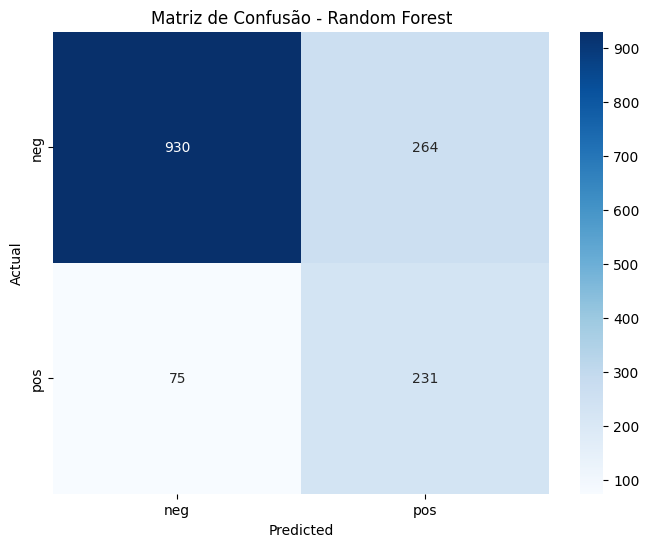

In [10]:
model_name = "Random Forest"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Gradient Boosting
              precision    recall  f1-score   support

           0     0.9302    0.7814    0.8493      1194
           1     0.4748    0.7712    0.5878       306

    accuracy                         0.7793      1500
   macro avg     0.7025    0.7763    0.7186      1500
weighted avg     0.8373    0.7793    0.7960      1500



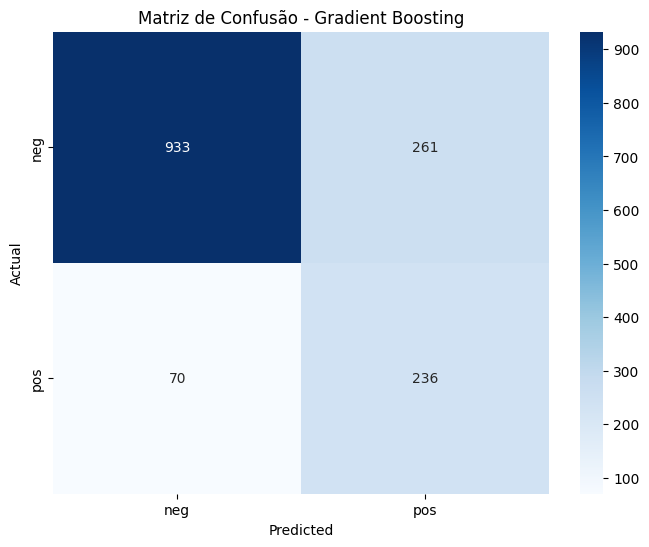

In [11]:
model_name = "Gradient Boosting"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: AdaBoost
              precision    recall  f1-score   support

           0     0.9156    0.7814    0.8432      1194
           1     0.4574    0.7190    0.5591       306

    accuracy                         0.7687      1500
   macro avg     0.6865    0.7502    0.7011      1500
weighted avg     0.8221    0.7687    0.7852      1500



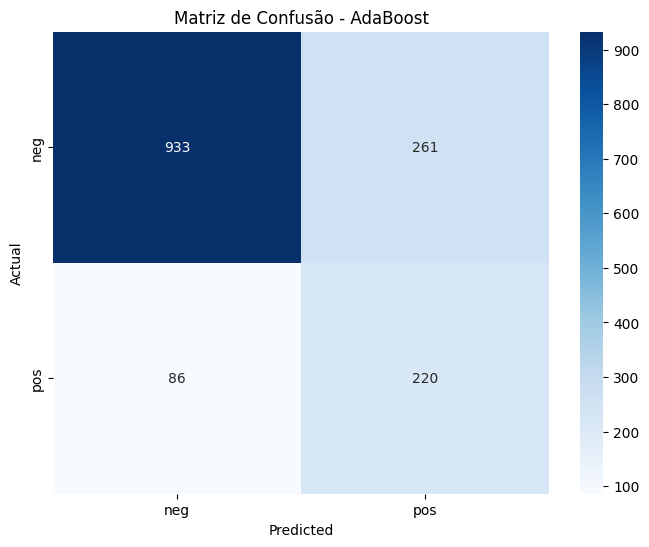

In [12]:
model_name = "AdaBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Bagging
              precision    recall  f1-score   support

           0     0.9159    0.7839    0.8448      1194
           1     0.4603    0.7190    0.5612       306

    accuracy                         0.7707      1500
   macro avg     0.6881    0.7514    0.7030      1500
weighted avg     0.8229    0.7707    0.7869      1500



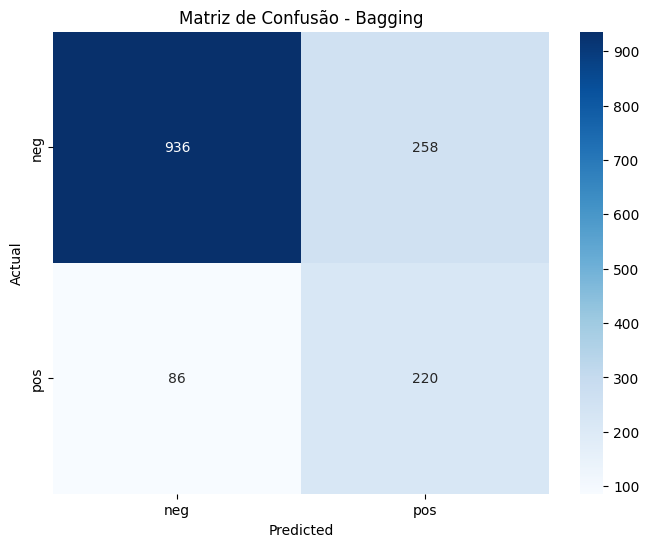

In [13]:
model_name = "Bagging"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Extra Trees
              precision    recall  f1-score   support

           0     0.9196    0.7755    0.8414      1194
           1     0.4564    0.7353    0.5632       306

    accuracy                         0.7673      1500
   macro avg     0.6880    0.7554    0.7023      1500
weighted avg     0.8251    0.7673    0.7847      1500



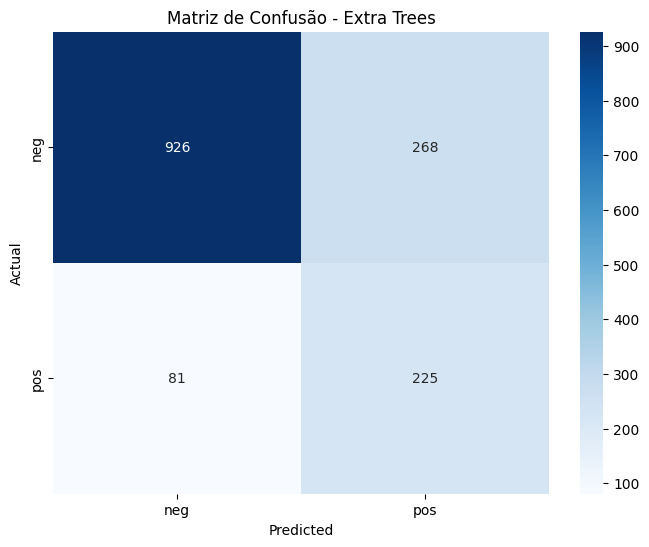

In [14]:
model_name = "Extra Trees"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: XGBoost
              precision    recall  f1-score   support

           0     0.9183    0.7630    0.8335      1194
           1     0.4429    0.7353    0.5528       306

    accuracy                         0.7573      1500
   macro avg     0.6806    0.7491    0.6932      1500
weighted avg     0.8214    0.7573    0.7762      1500



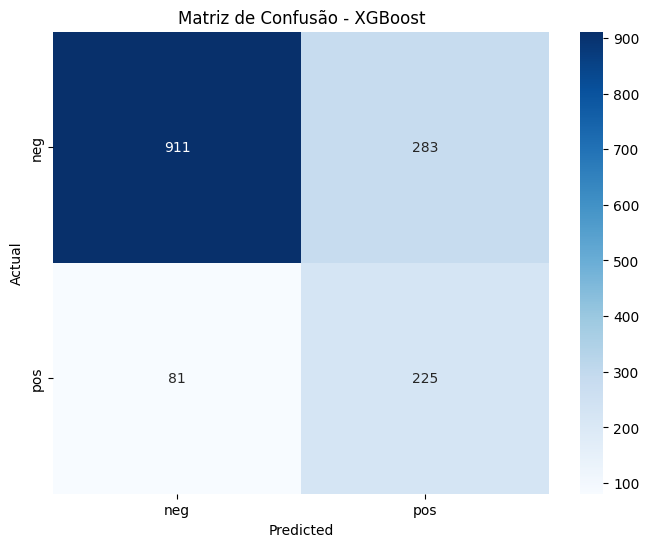

In [17]:
model_name = "XGBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: LightGBM
[LightGBM] [Info] Number of positive: 1426, number of negative: 1426
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 2852, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0     0.9224    0.7663    0.8371      1194
           1     0.4508    0.7484    0.5627       306

    accuracy                         0.7627      1500
   macro avg     0.6866    0.7573    0.6999      1500
weighted avg     0.8262    0.7627    0.7811      1500



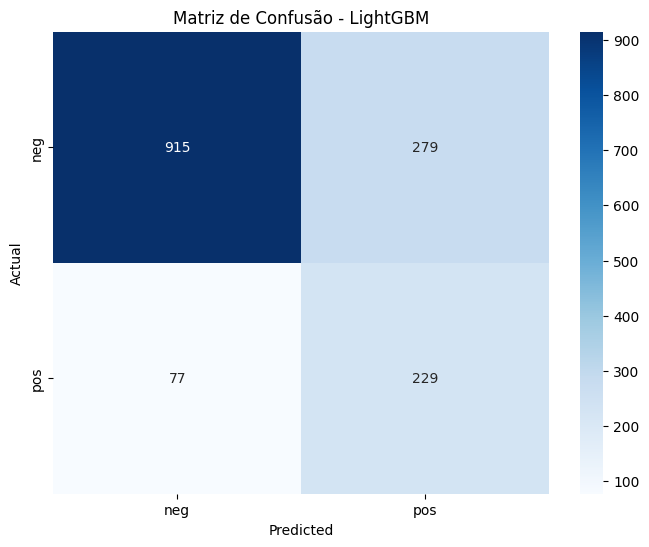

In [18]:
model_name = "LightGBM"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

# Otimização de Hiperparâmetros

In [ ]:
param_grids = {
    "Random Forest": {
        "model_instance": RandomForestClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Gradient Boosting": {
        "model_instance": GradientBoostingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        }
    },
    "AdaBoost": {
        "model_instance": AdaBoostClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
        }
    },
    "Bagging": {
        "model_instance": BaggingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 10, 200),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Extra Trees": {
        "model_instance": ExtraTreesClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "XGBoost": {
        "model_instance": XGBClassifier(verbosity=0, use_label_encoder=False),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
    "LightGBM": {
        "model_instance": LGBMClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "num_leaves": trial.suggest_int("num_leaves", 7, 256),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
}

In [20]:
def objective(trial, model_instance, param_grid, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    params = param_grid(trial)
    clf = model_instance.__class__(**params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)

    train_f1 = f1_score(y_train, clf.predict(X_train))
    trial.set_user_attr("train_f1_score", train_f1)
    
    return f1_score(y_val, y_pred, pos_label=1)

In [21]:
tuning_results = dict()

optuna.logging.set_verbosity(optuna.logging.WARNING)
for model_name, clf_data in list(param_grids.items()):
    print(f'Otimizando: {model_name}')
    study = optuna.create_study(direction='maximize')
    
    study.optimize(lambda trial: objective(trial, clf_data['model_instance'], clf_data['params']), n_trials=300)
    best_params = study.best_params
    trials = study.trials_dataframe()
    tuning_results[model_name] = dict()
    tuning_results[model_name]['best_params'] = best_params
    tuning_results[model_name]['trials'] = trials

Otimizando: Logistic Regression
Otimizando: Random Forest
Otimizando: Gradient Boosting
Otimizando: AdaBoost
Otimizando: Bagging
Otimizando: Extra Trees
Otimizando: KNN
Otimizando: XGBoost
Otimizando: LightGBM
[LightGBM] [Info] Number of positive: 1426, number of negative: 5574
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203714 -> initscore=-1.363240
[LightGBM] [Info] Start training from score -1.363240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Avaliação dos Modelos

In [22]:
for key, value in tuning_results.items():
    results = tuning_results[key]
    best_params = results['best_params']
    
    model = param_grids[key]['model_instance'].__class__(**best_params)

    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    # print(classification_report(y_test, prediction))

    cm = confusion_matrix(y_test, prediction)
    # plot_confusion_matrix(cm, 'Matriz de Confusão')

    cost_matrix = [[0, 230], [791.40, 0]]
    cost_result = np.sum(cm * cost_matrix)
    cost_results[f"Optmized_{key}"] = cost_result

[LightGBM] [Info] Number of positive: 1426, number of negative: 5574
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203714 -> initscore=-1.363240
[LightGBM] [Info] Start training from score -1.363240


In [23]:
cost_results_df = pd.DataFrame(list(cost_results.items()), columns=['Modelo', 'Custo dos Erros'])
cost_results_df = cost_results_df.sort_values(by='Custo dos Erros', ascending=True)
cost_results_df.reset_index(drop=True, inplace=True)
cost_results_df['Custo dos Erros'] = cost_results_df['Custo dos Erros'].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
cost_results_df

,Modelo,Custo dos Erros
0,Baseline_Gradient Boosting,"R$ 115.428,00"
1,Baseline_Random Forest,"R$ 120.075,00"
2,Baseline_LightGBM,"R$ 125.107,80"
3,Baseline_Extra Trees,"R$ 125.743,40"
4,Baseline_Bagging,"R$ 127.400,40"
5,Baseline_AdaBoost,"R$ 128.090,40"
6,Baseline_XGBoost,"R$ 129.193,40"
7,Optmized_LightGBM,"R$ 133.504,20"
8,Optmized_Gradient Boosting,"R$ 135.344,20"
9,Optmized_XGBoost,"R$ 135.547,00"


In [24]:
def plot_train_vs_val_overview(trials_df, model_name):
    """
    Plota um comparativo entre o resultado de treino e validação do modelo durante a otimização do Optuna.
    Espera que o trials_df contenha as colunas 'user_attrs_train_score' e 'value' (validação).
    """

    plt.figure(figsize=(12, 6))
    plt.plot(trials_df['number'], trials_df['user_attrs_train_f1_score'], label='F1 Score Treino', marker='o')
    plt.plot(trials_df['number'], trials_df['value'], label='F1 Score Validação', marker='o')
    plt.xlabel("Número do Trial")
    plt.ylabel("F1 Score")
    plt.title("Comparativo de F1 Score: Treino vs Validação durante a Otimização")
    plt.legend()
    plt.grid(True)
    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()
    plt.close()


In [25]:
def plot_detailed_overview(trials_df, model_name):
    # Seleciona apenas as colunas dos hiperparâmetros reais (ignora colunas auxiliares como 'params_str')
    param_cols = [col for col in trials_df.columns if col.startswith('params_') and col != 'params_str']
    num_params = len(param_cols)

    ncols = 2
    nrows = math.ceil(num_params / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
    axes = axes.flatten()

    for i, param in enumerate(param_cols):
        ax = axes[i]
        # Agrupa por valor do parâmetro e calcula a média do valor objetivo ('value')
        grouped = trials_df.groupby(param)['value'].mean().reset_index()
        ax.plot(grouped[param], grouped['value'], marker='o', linestyle='-')
        ax.set_title(f"Métrica vs {param.replace('params_', '')}")
        ax.set_xlabel(param.replace('params_', ''))
        ax.set_ylabel("F1 Score da Validação")
        ax.grid(True)

    # Oculta os eixos não utilizados
    for j in range(num_params, len(axes)):
        axes[j].axis('off')

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()
    plt.close()

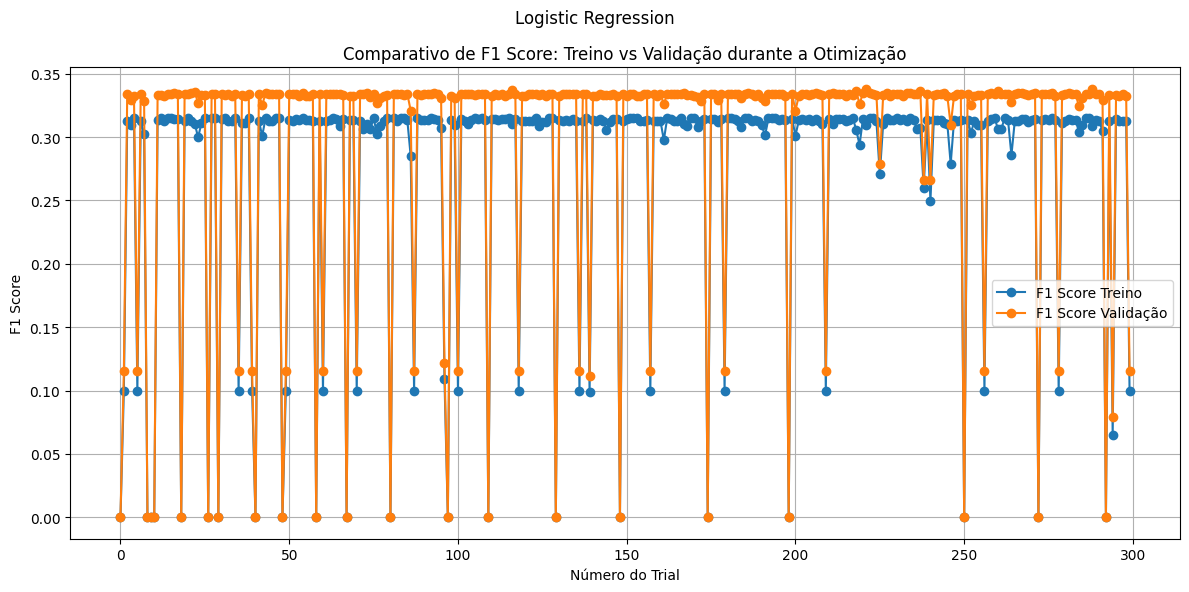

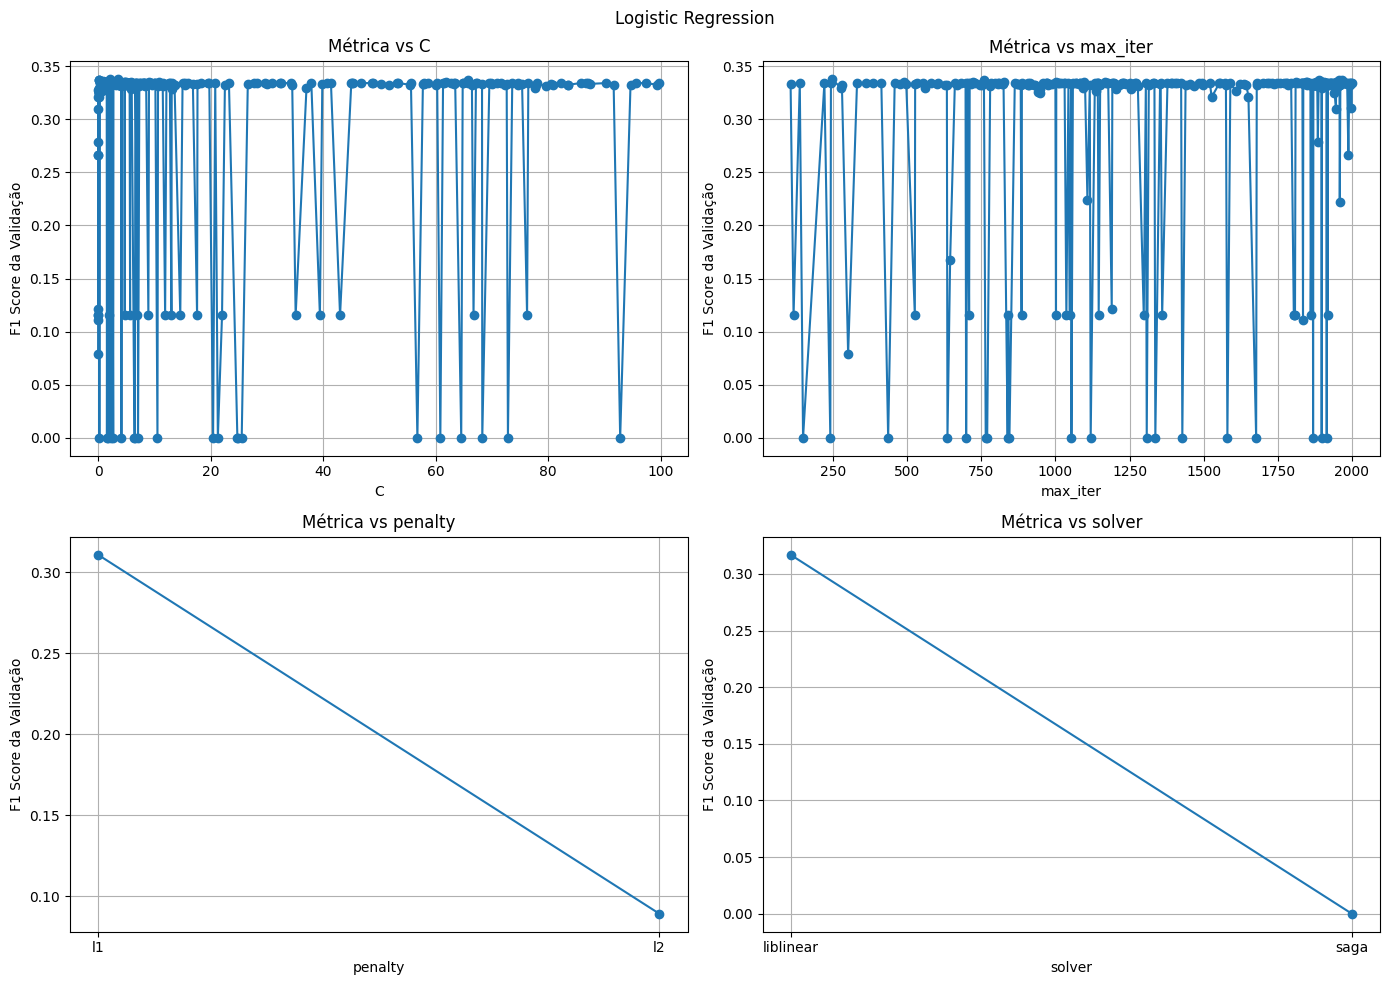

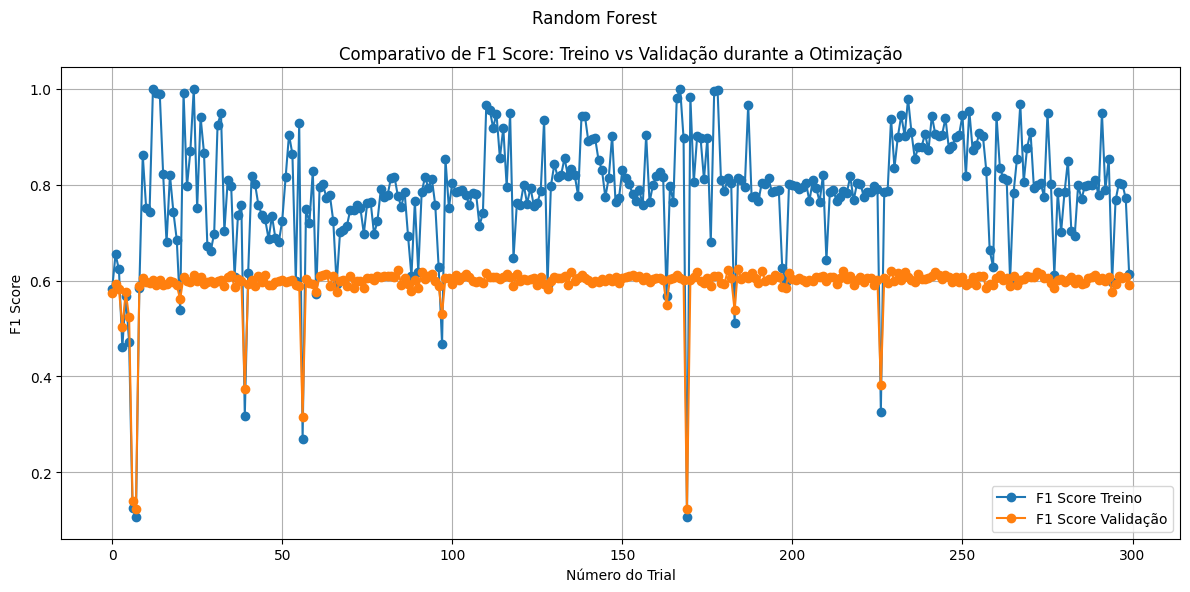

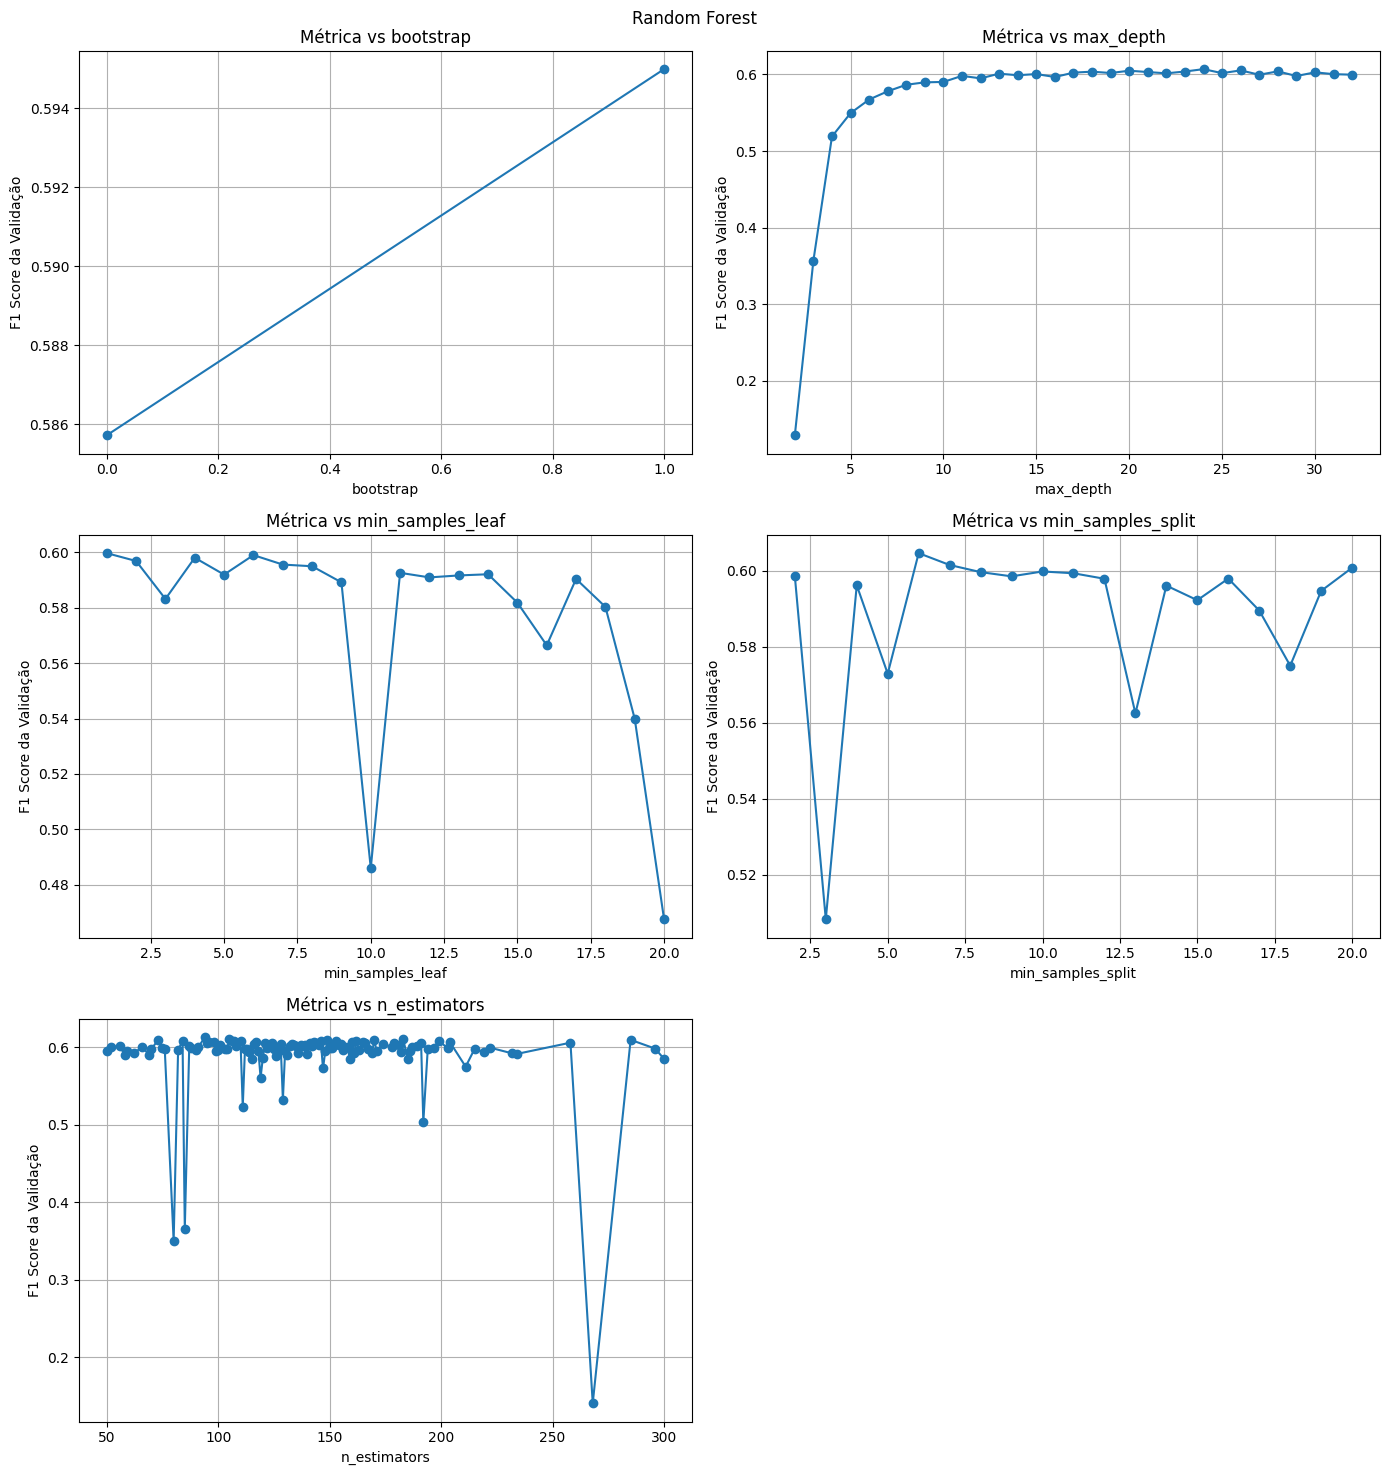

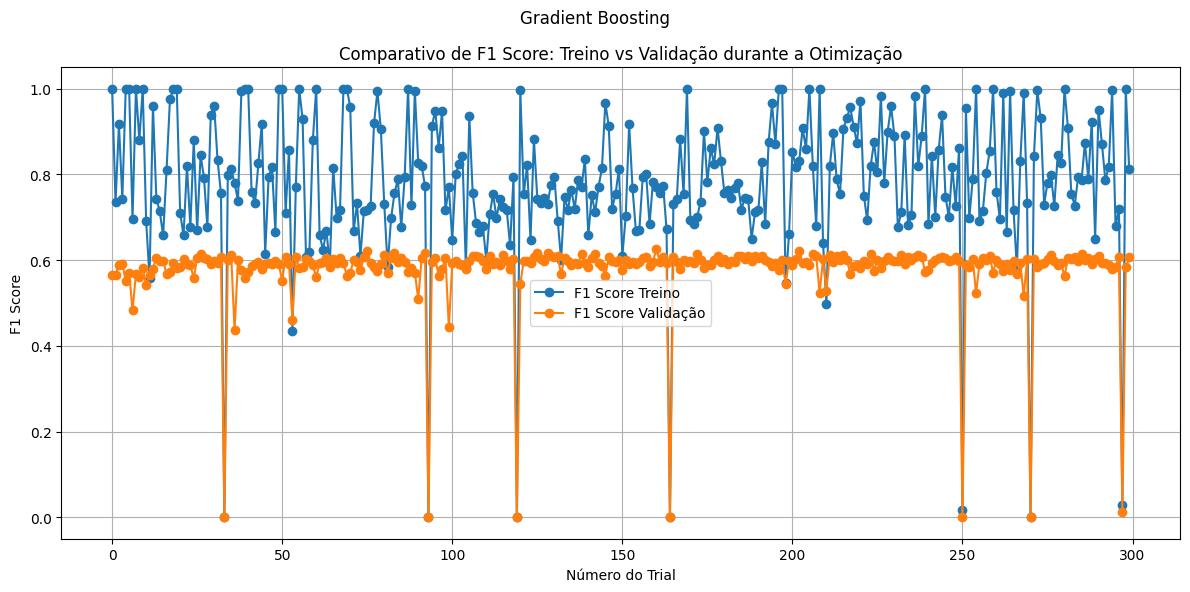

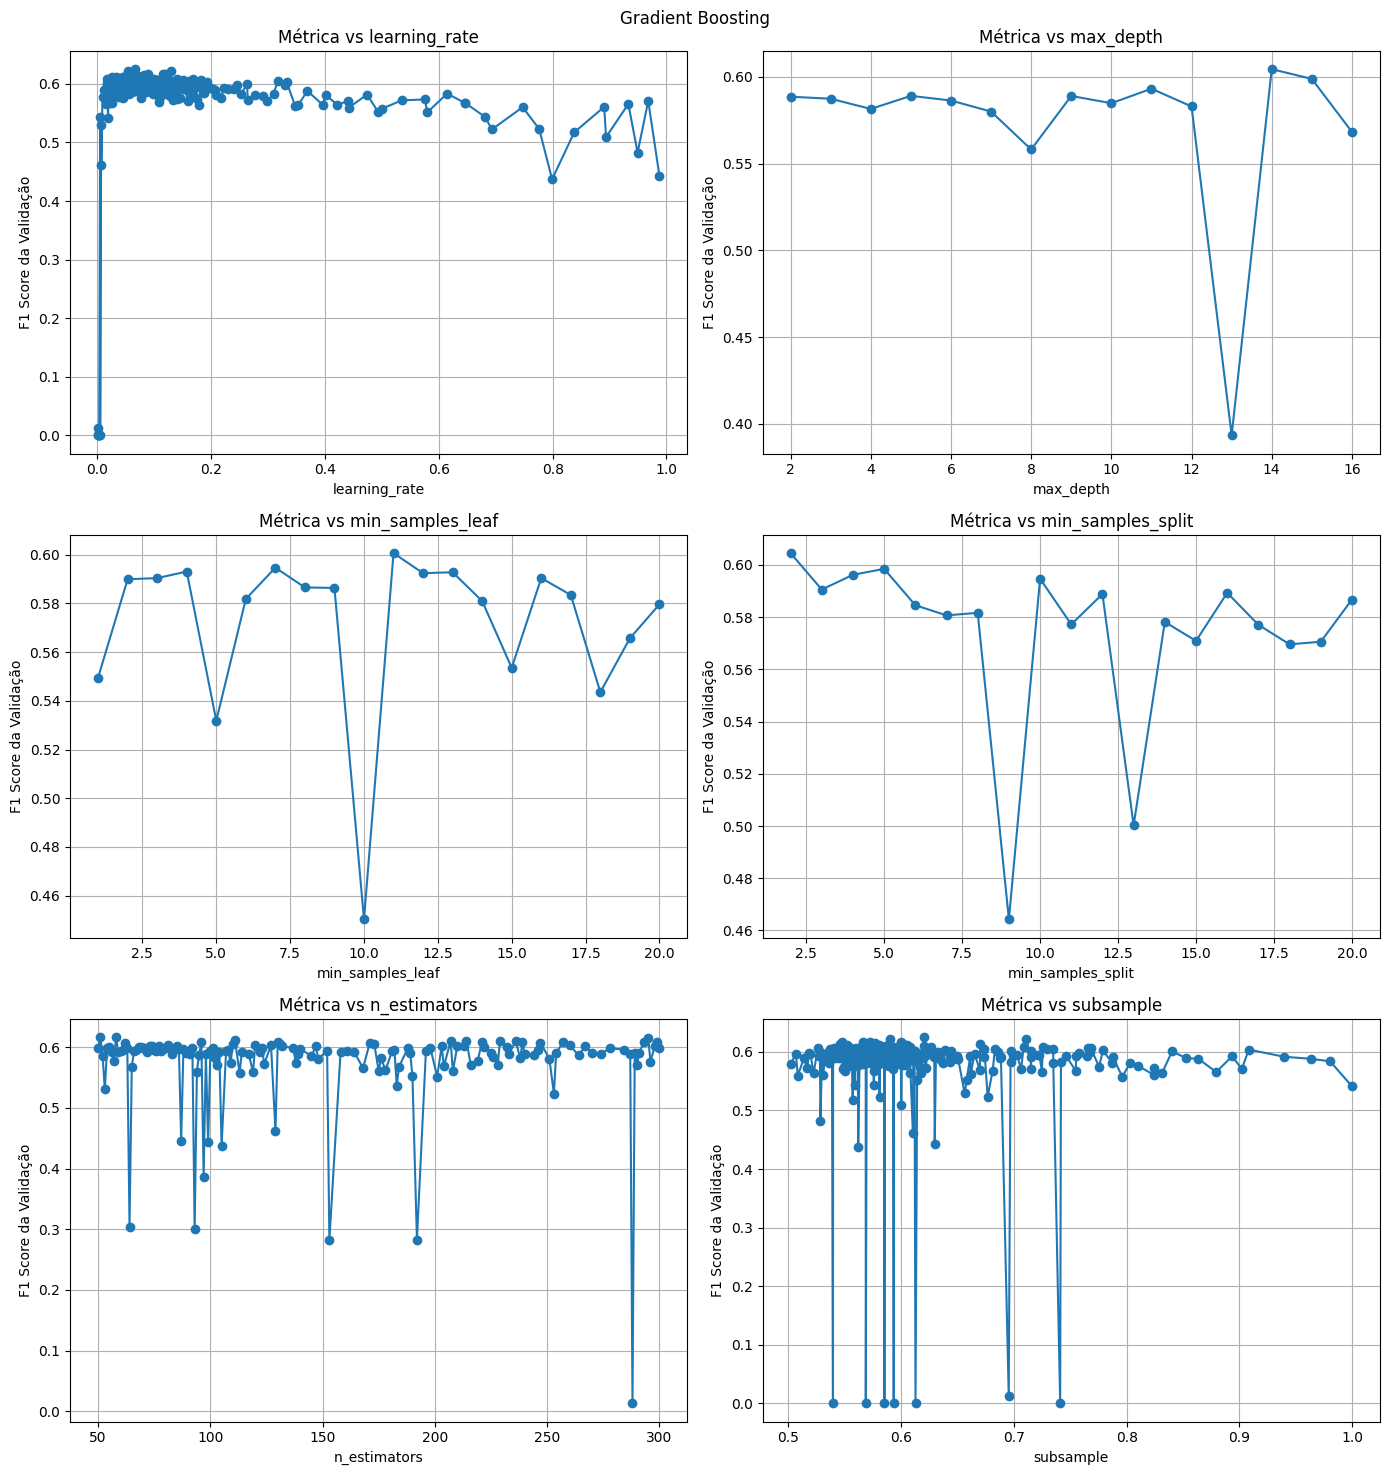

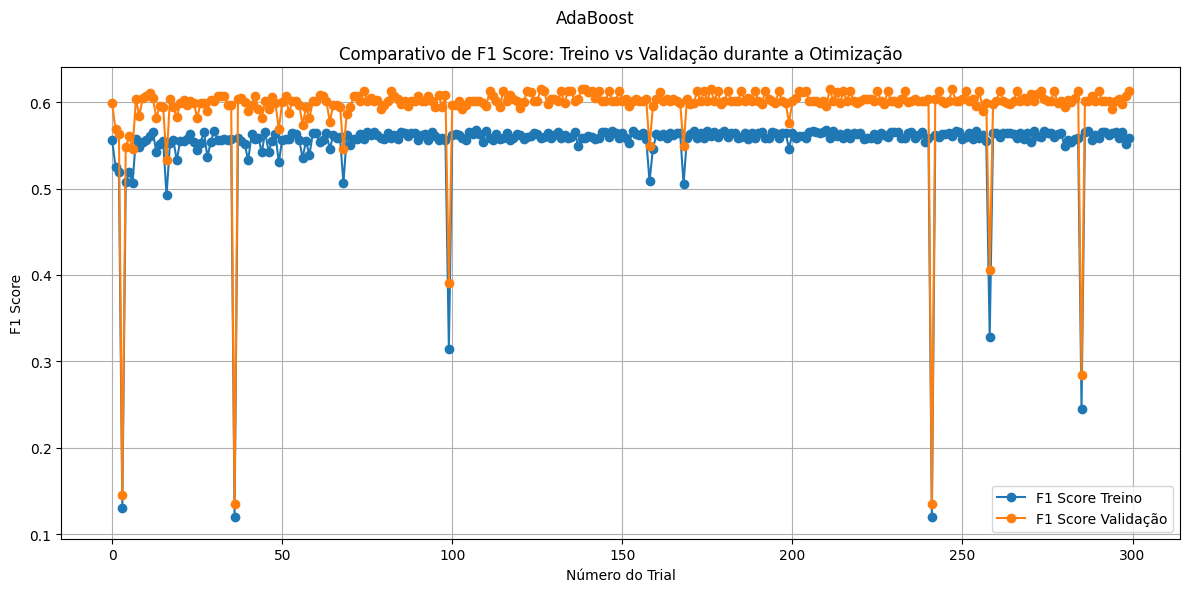

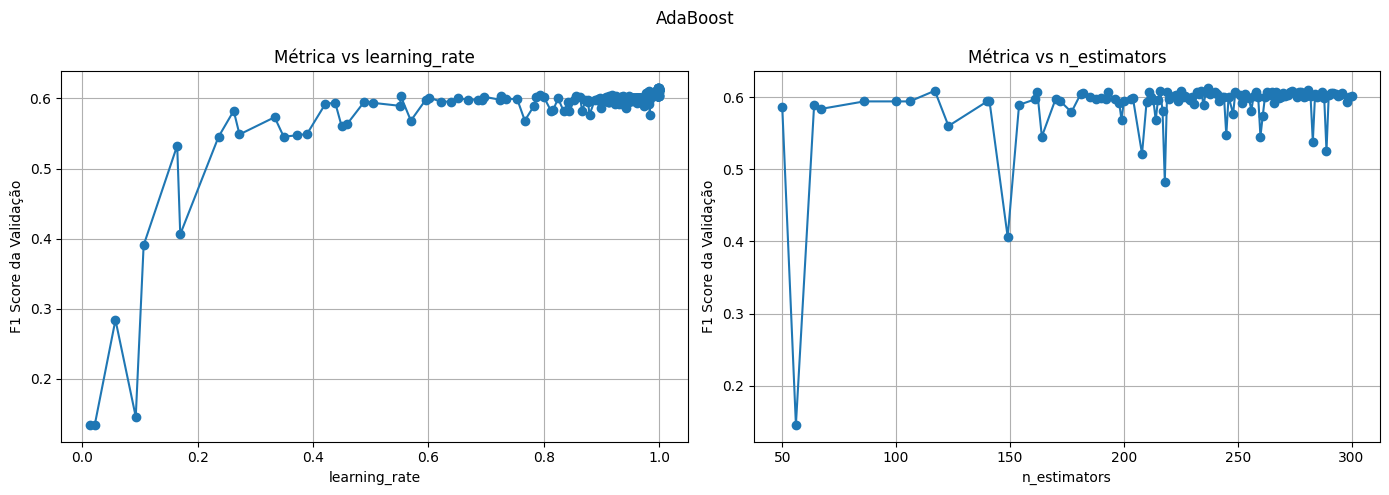

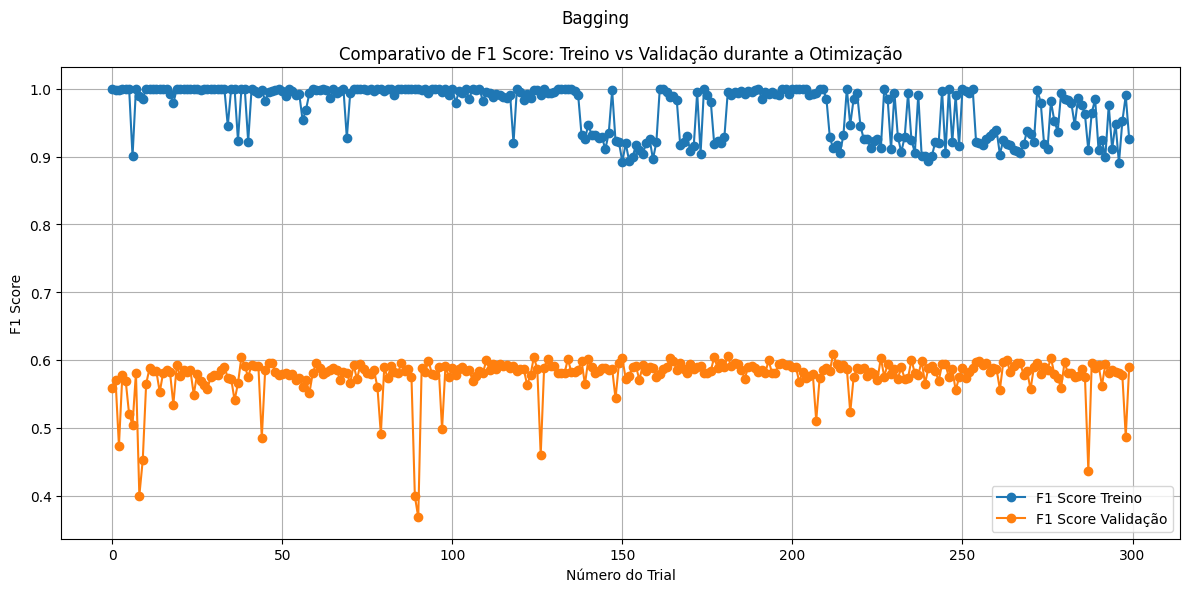

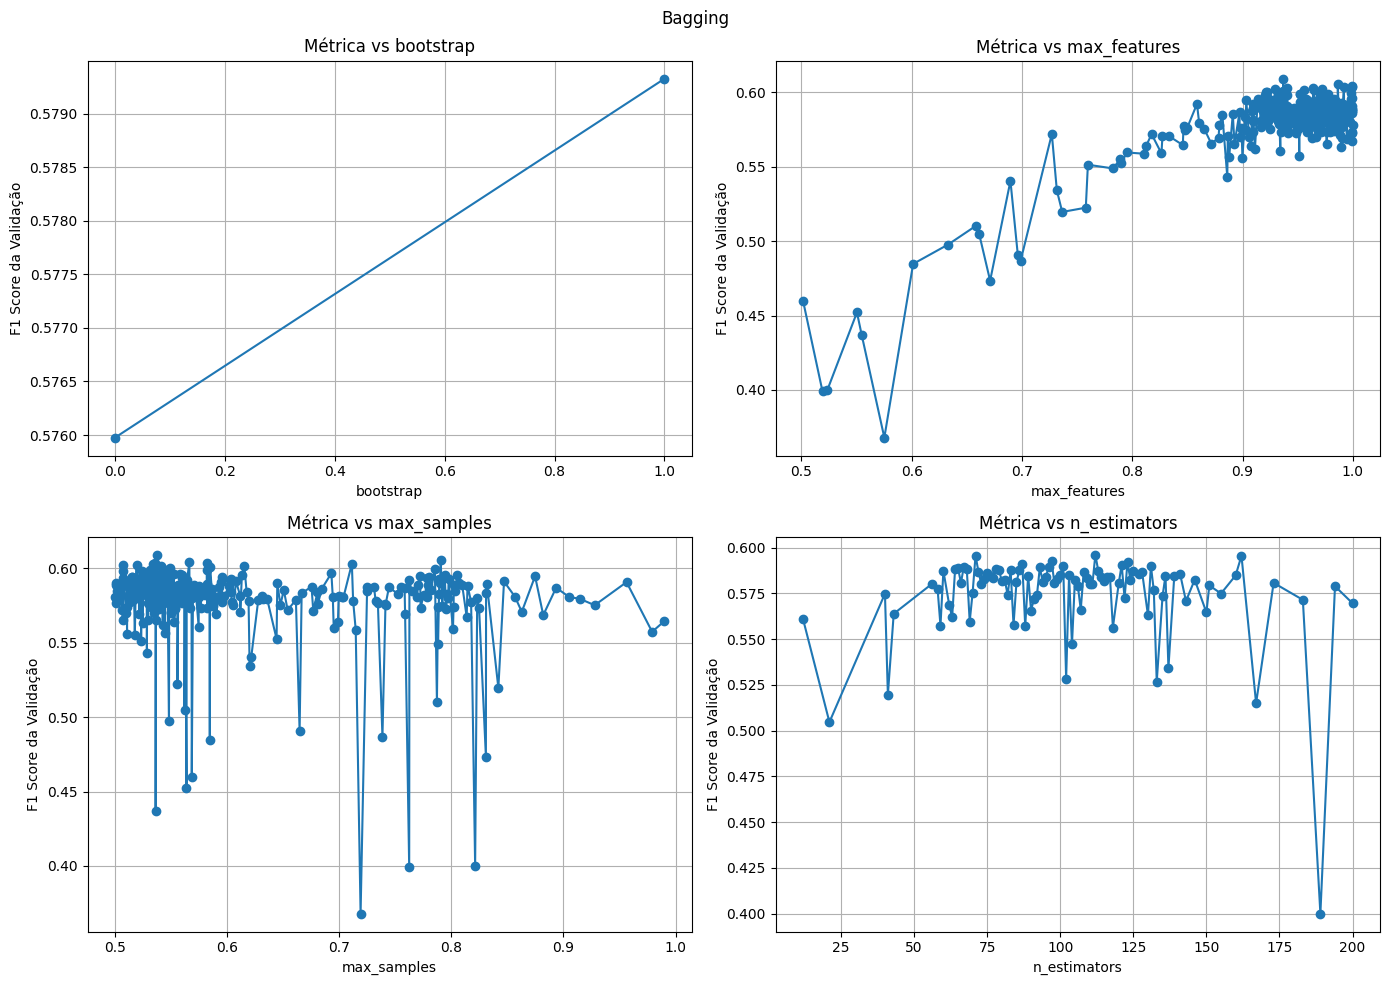

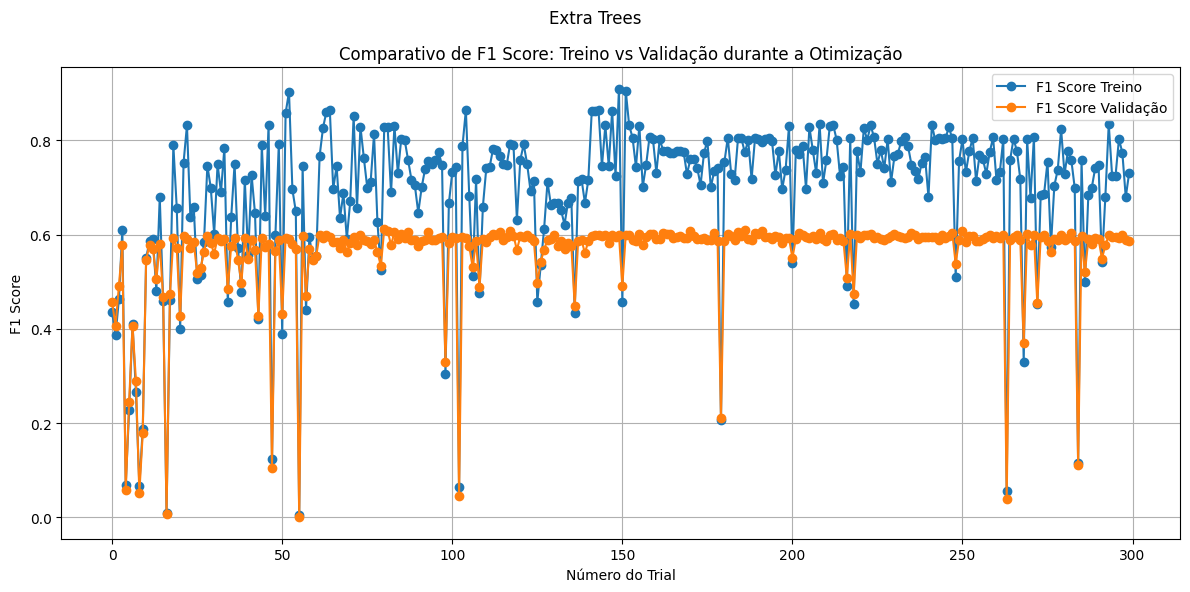

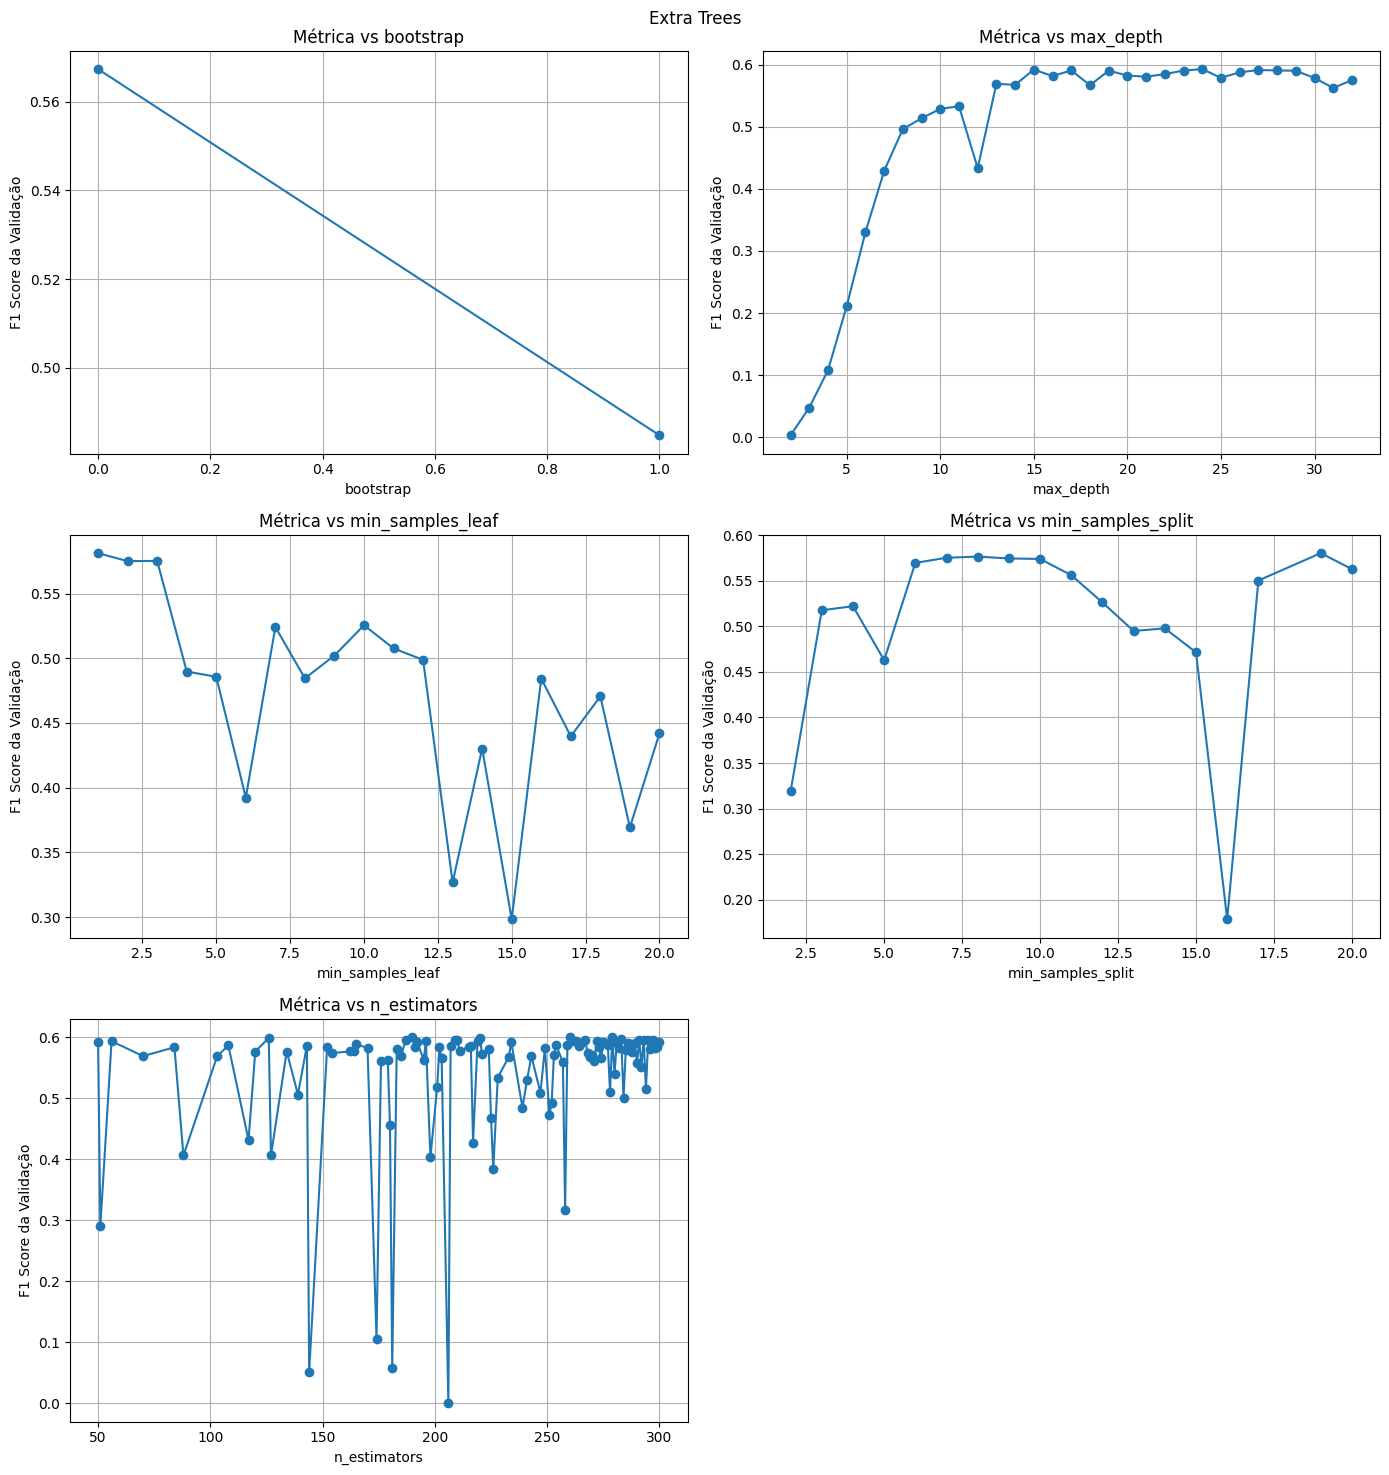

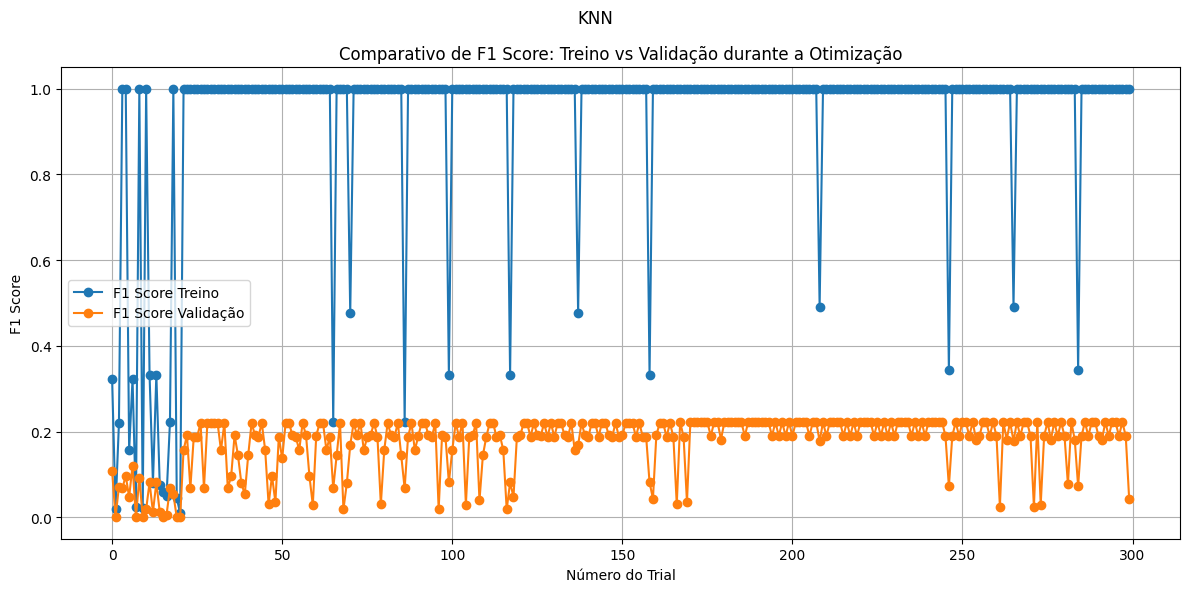

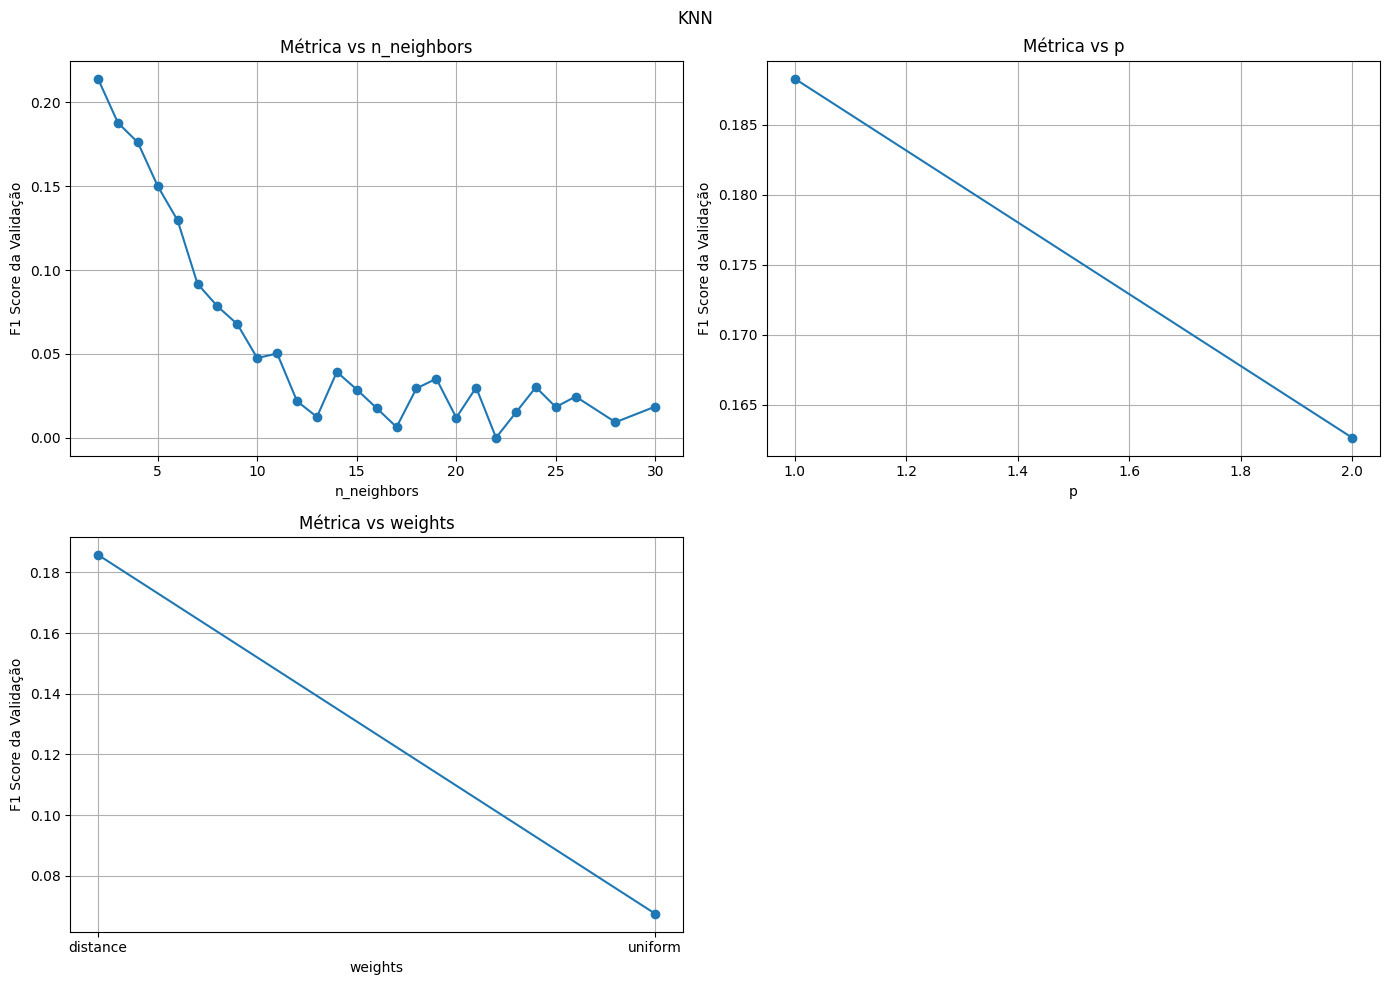

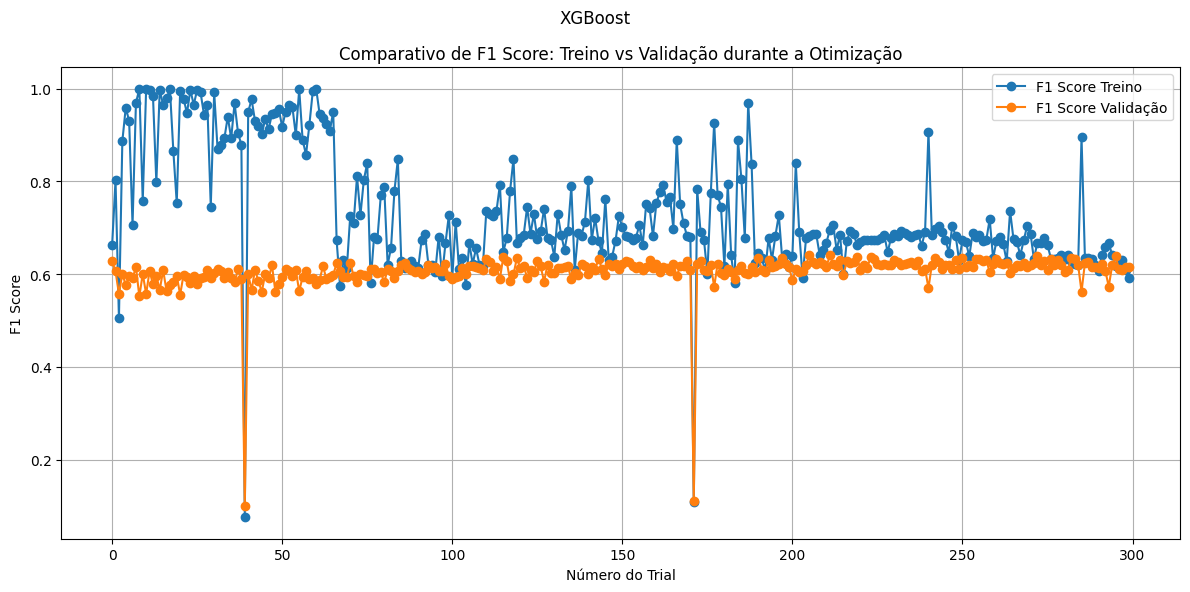

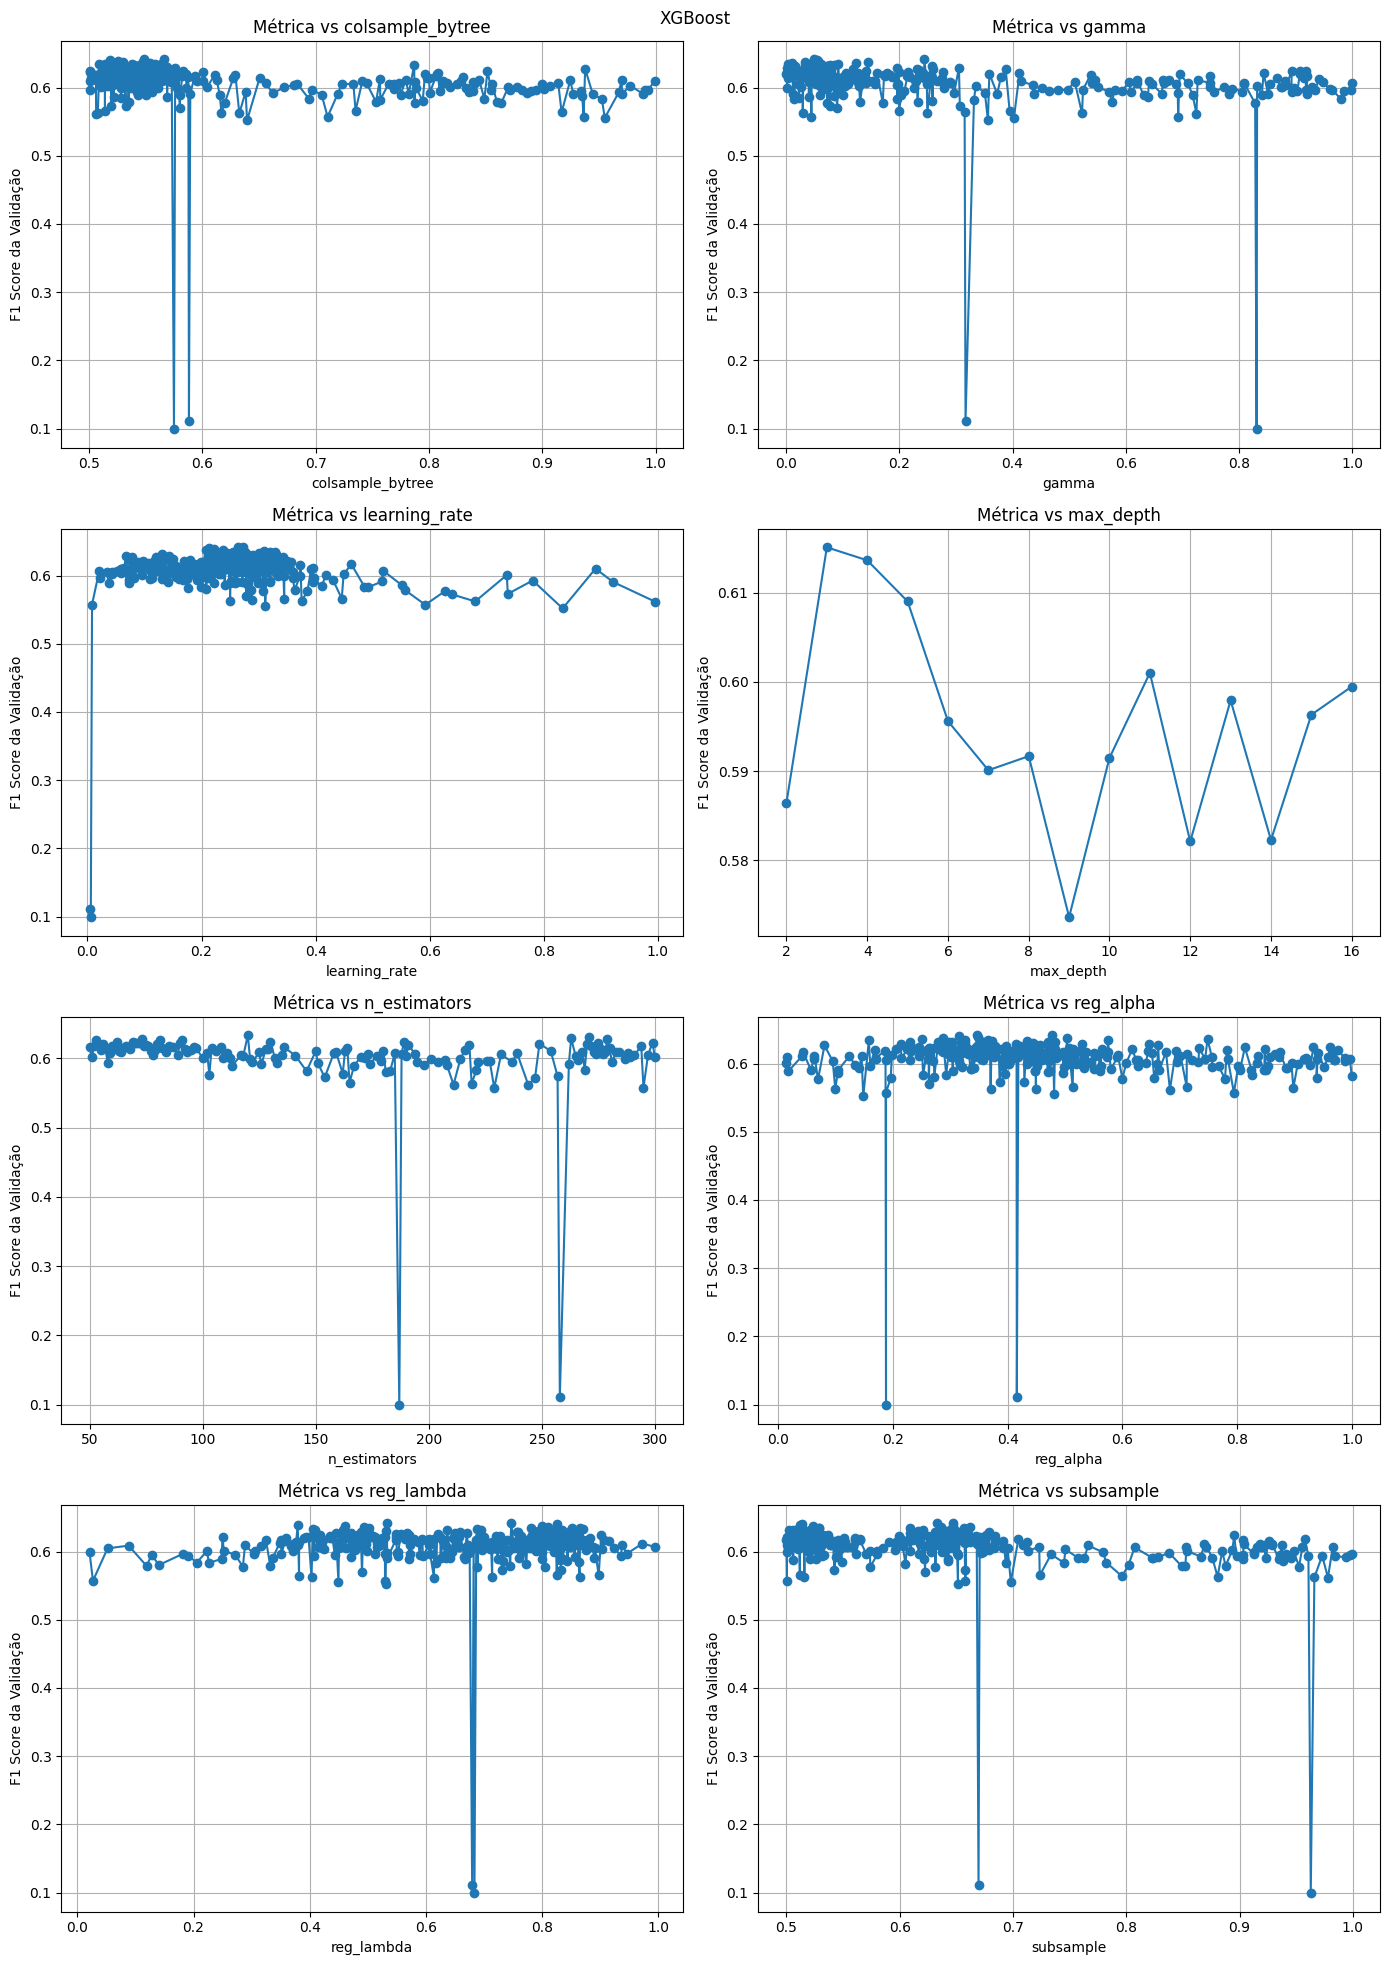

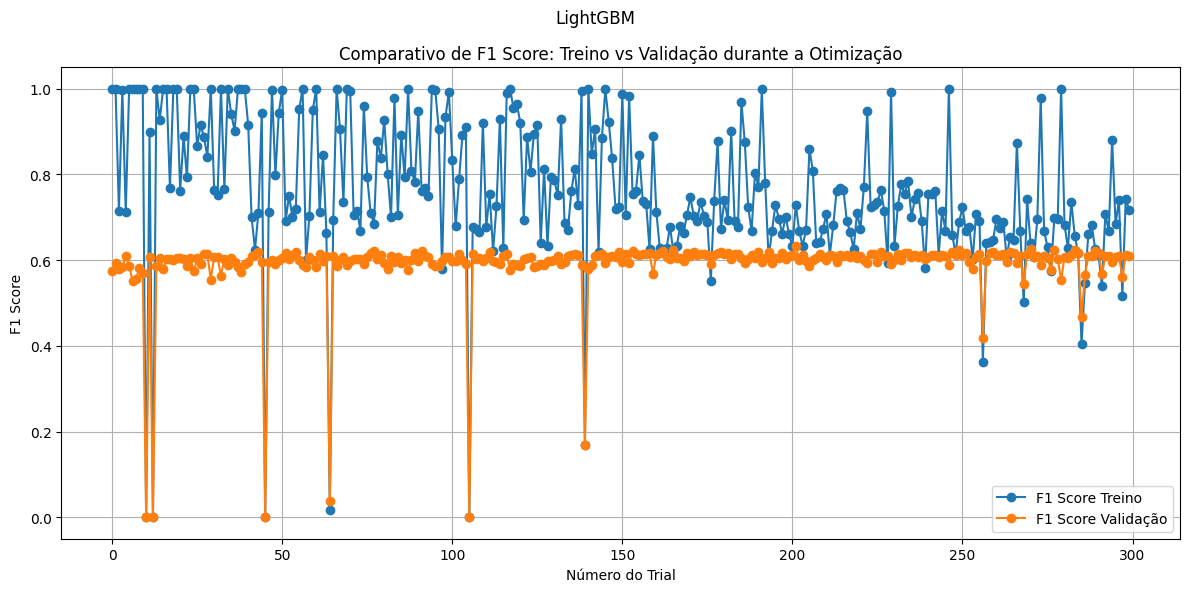

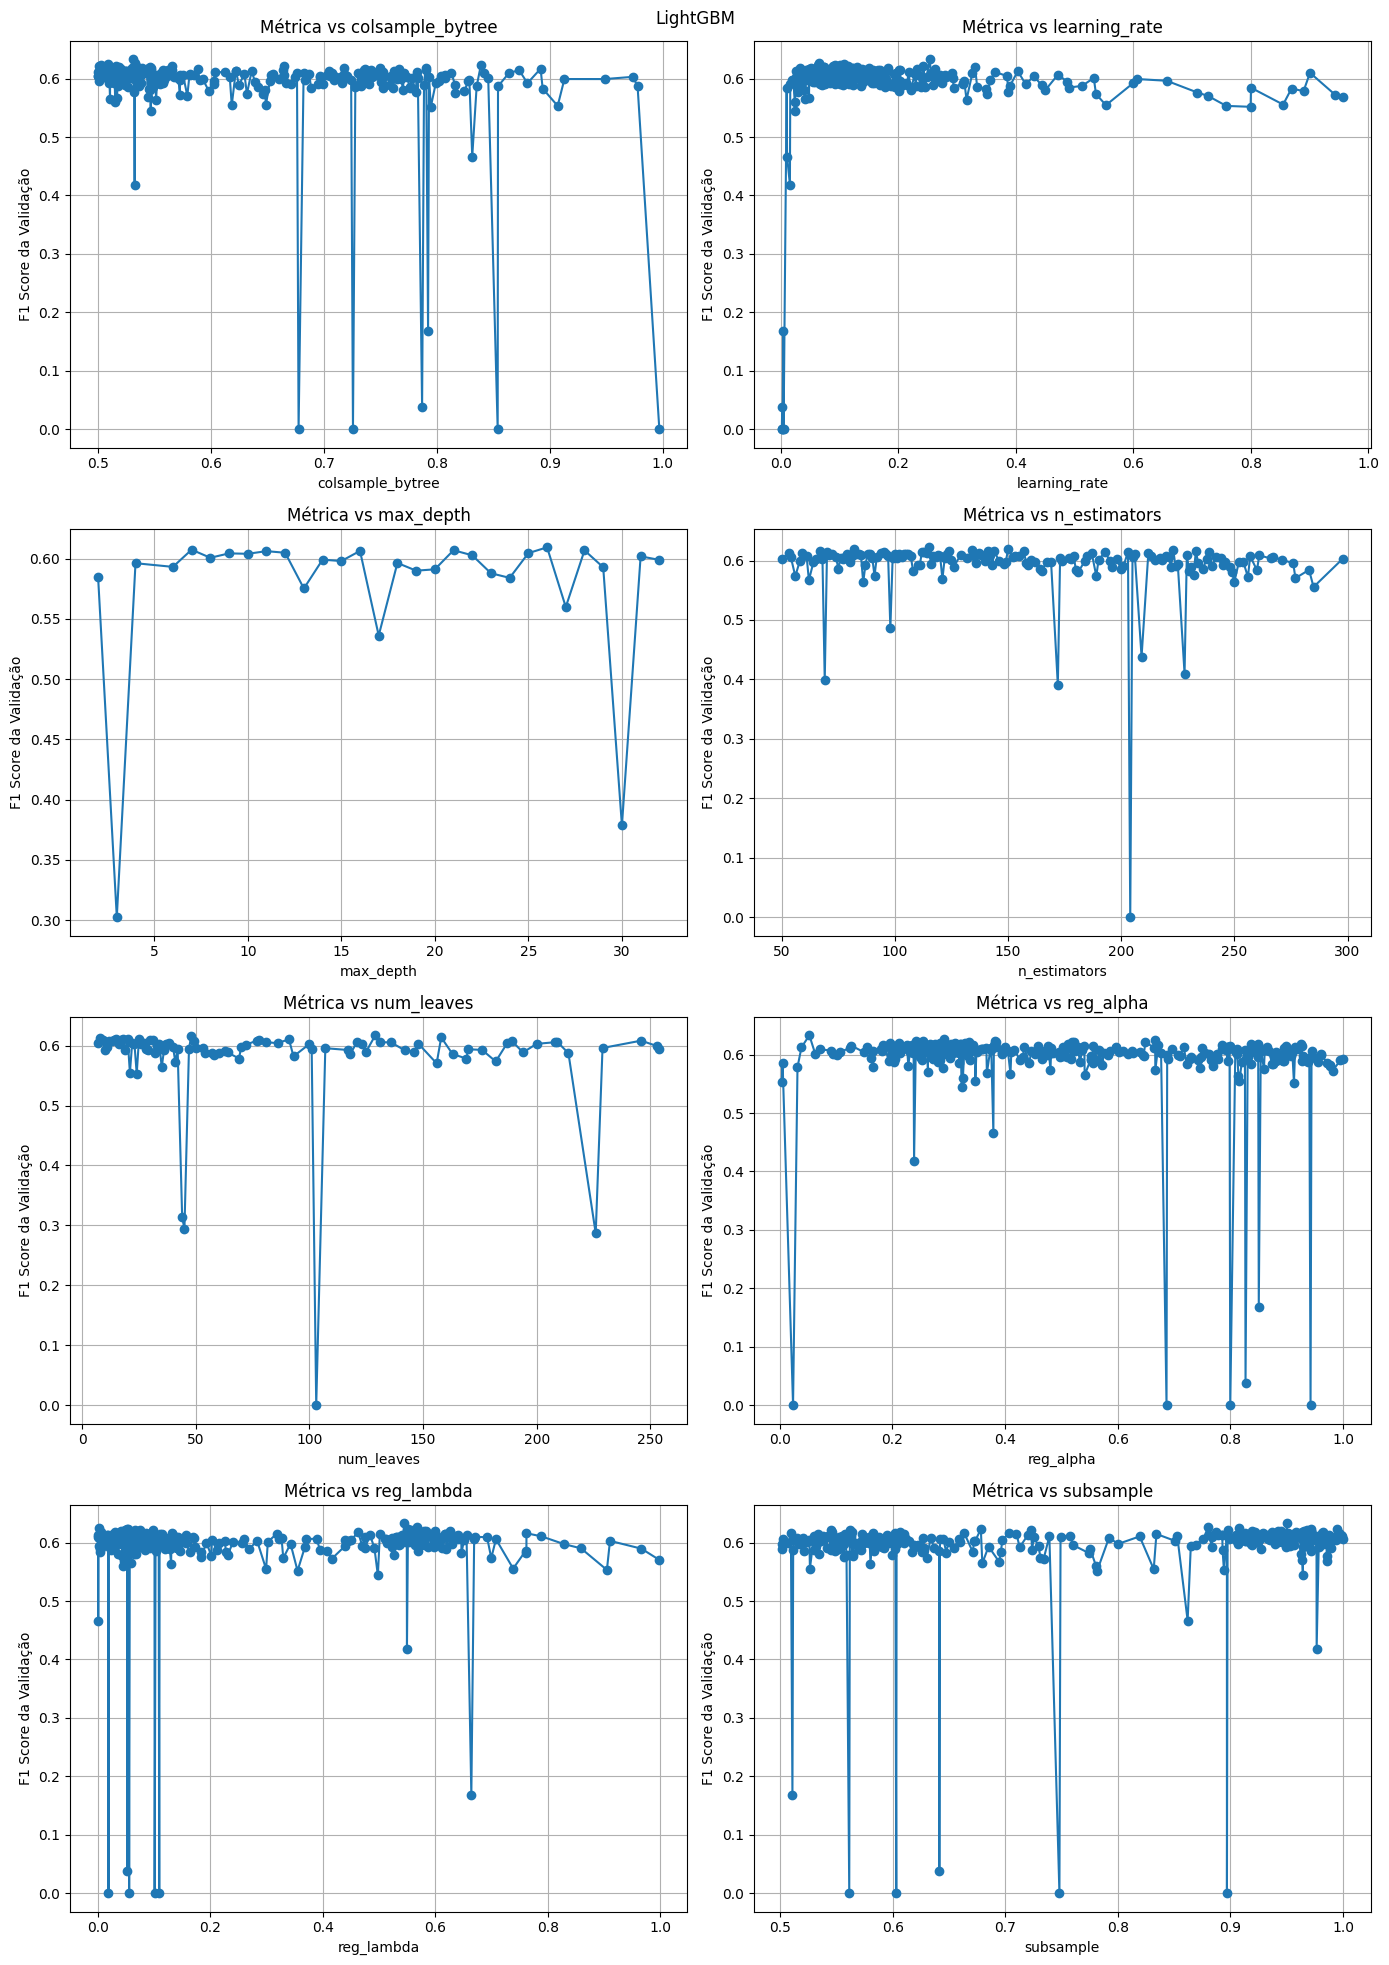

In [26]:
for key, value in tuning_results.items():
    data = tuning_results[key]
    
    plot_train_vs_val_overview(data['trials'], key)
    plot_detailed_overview(data['trials'], key)